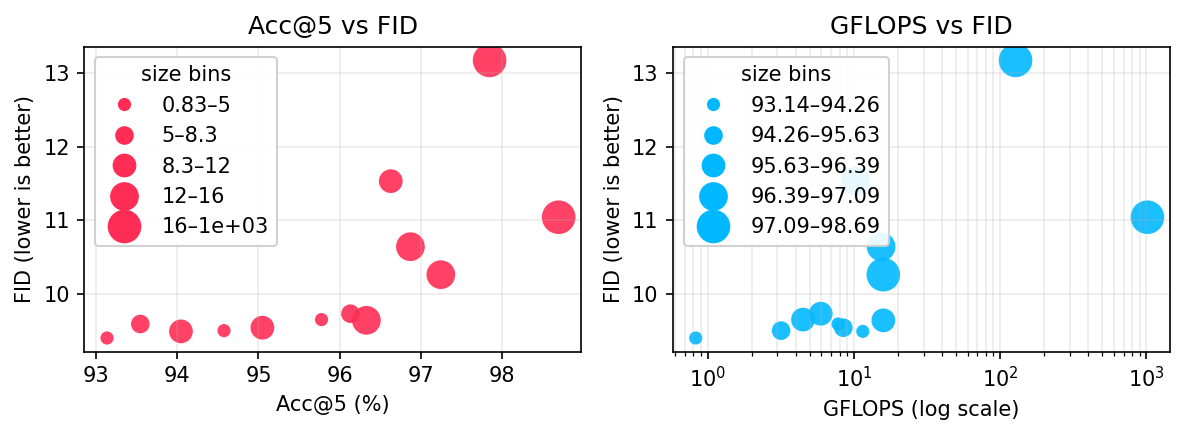

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Data -----
rows = [
  ("vit_h_14",          98.694, 1016.72, 11.04),
  ("regnet_y_128gf",    97.844, 127.52,  13.17),
  ("regnet_y_16gf_v1",  97.244, 15.91,   10.26),
  ("convnext_base",     96.870, 15.36,   10.64),
  ("efficientnet_b5",   96.628, 10.27,   11.53),
  ("regnet_y_16gf_v2",  96.328, 15.91,    9.64),
  ("swin_v2_t",         96.132, 5.94,     9.73),
  ("swin_t",            95.776, 4.49,     9.65),
  ("regnet_y_32gf",     95.340, 32.28,    None),
  ("regnet_y_8gf",      95.048, 8.47,     9.54),
  ("regnet_y_3_2gf",    94.576, 3.18,     9.50),
  ("resnet152",         94.046, 11.51,    9.49),
  ("resnet101",         93.546, 7.80,     9.59),
  ("regnet_y_800mf",    93.136, 0.83,     9.40),
  ("mobilenet_v3_large",92.566, 0.22,     None),
  ("regnet_y_400mf",    91.716, 0.40,     None),
  ("regnet_x_400mf",    90.950, 0.41,     None),
  ("mobilenet_v2",      90.286, 0.30,     None),
  ("shufflenet_v2_x1_0",88.316, 0.14,     None),
  ("alexnet",           79.066, 0.71,     None),
]

rows = [r for r in rows if r[3] is not None]
names  = np.array([r[0] for r in rows])
acc5   = np.array([r[1] for r in rows], dtype=float)
gflops = np.array([r[2] for r in rows], dtype=float)
fid    = np.array([r[3] for r in rows], dtype=float)

# ----- Helpers -----
N_BINS = 5
SIZE_LEVELS = np.array([40, 80, 130, 190, 260], dtype=float)  # pt^2

def log_quantile_edges(x, n_bins):
    lx = np.log10(x)
    edges = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < n_bins + 1:
        edges = np.linspace(lx.min(), lx.max(), n_bins + 1)
    return 10 ** edges

def quantile_edges(x, n_bins):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < n_bins + 1:
        edges = np.linspace(float(x.min()), float(x.max()), n_bins + 1)
    return edges

def sizes_from_bins(x, edges, size_levels=SIZE_LEVELS):
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(size_levels)-1)
    return size_levels[idx]

# Bin edges & sizes
edges_g = log_quantile_edges(gflops, N_BINS)   # for GFLOPS bins (left size)
sizes_L = sizes_from_bins(gflops, edges_g)

edges_a = quantile_edges(acc5, N_BINS)         # for Acc@5 bins (right size)
sizes_R = sizes_from_bins(acc5, edges_a)

# ----- Subplots (1×2) -----
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Left: Acc@5 vs FID  (size = GFLOPS bins), color = #FF2D55
ax = axes[0]
ax.scatter(acc5, fid, s=sizes_L, c="#FF2D55", marker='o', alpha=0.9, edgecolors='none')
ax.set_xlabel("Acc@5 (%)")
ax.set_ylabel("FID (lower is better)")
ax.set_title("Acc@5 vs FID")
ax.grid(True, alpha=0.25)

# Legend with only numeric ranges
handles_L = []
for b, sz in enumerate(SIZE_LEVELS):
    lo = edges_g[b]
    hi = edges_g[b+1] if b+1 < len(edges_g) else None
    label = f"{lo:.2g}–{hi:.2g}" if hi is not None else f">{lo:.2g}"
    handles_L.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#FF2D55",
                            markeredgecolor='none', markersize=(sz**0.5)))
ax.legend(handles=handles_L, title="size bins", loc='best', framealpha=0.9)

# Right: GFLOPS vs FID  (size = Acc@5 bins), color = #00B8FF
ax = axes[1]
ax.scatter(gflops, fid, s=sizes_R, c="#00B8FF", marker='o', alpha=0.9, edgecolors='none')
ax.set_xscale("log")
ax.set_xlabel("GFLOPS (log scale)")
ax.set_ylabel("FID (lower is better)")
ax.set_title("GFLOPS vs FID")
ax.grid(True, which="both", alpha=0.25)

handles_R = []
for b, sz in enumerate(SIZE_LEVELS):
    lo = edges_a[b]
    hi = edges_a[b+1] if b+1 < len(edges_a) else None
    label = f"{lo:.2f}–{hi:.2f}" if hi is not None else f">{lo:.2f}"
    handles_R.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#00B8FF",
                            markeredgecolor='none', markersize=(sz**0.5)))
ax.legend(handles=handles_R, title="size bins", loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()


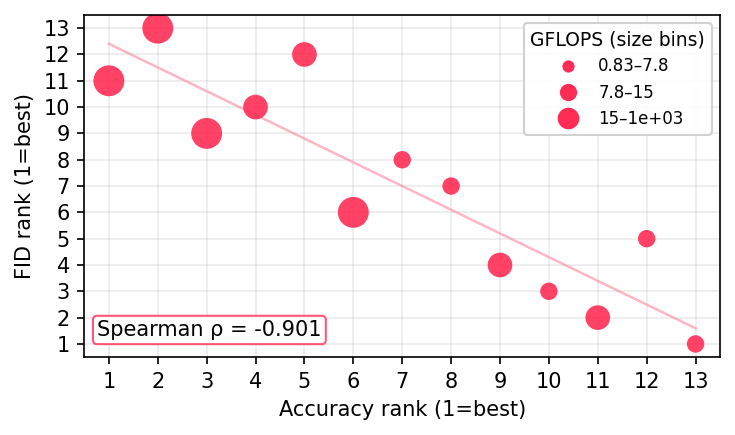

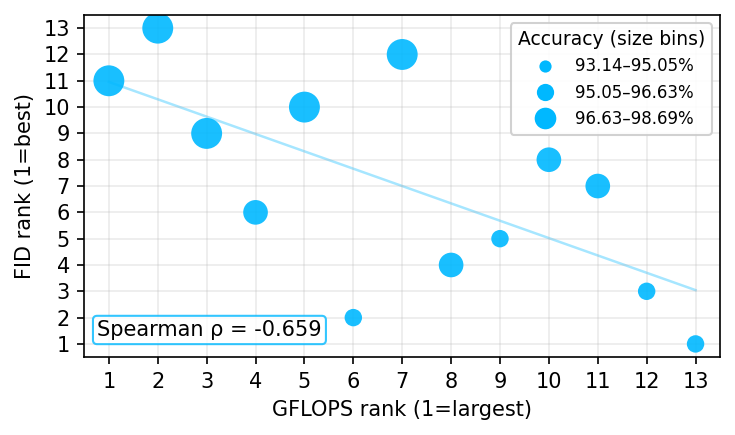

In [4]:
# Update labels to use "Accuracy" (not "Acc" / "Acc@5"). 
# - Left: Accuracy rank vs FID rank (size = GFLOPS bins)
# - Right: GFLOPS rank vs FID rank (size = Accuracy bins)
# Keep: 3-bin legends, lighter regression lines, Spearman rho annotations, legends upper-right, no titles.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Data -----
rows = [
  ("vit_h_14",          98.694, 1016.72, 11.04),
  ("regnet_y_128gf",    97.844, 127.52,  13.17),
  ("regnet_y_16gf_v1",  97.244, 15.91,   10.26),
  ("convnext_base",     96.870, 15.36,   10.64),
  ("efficientnet_b5",   96.628, 10.27,   11.53),
  ("regnet_y_16gf_v2",  96.328, 15.91,    9.64),
  ("swin_v2_t",         96.132, 5.94,     9.73),
  ("swin_t",            95.776, 4.49,     9.65),
  ("regnet_y_8gf",      95.048, 8.47,     9.54),
  ("regnet_y_3_2gf",    94.576, 3.18,     9.50),
  ("resnet152",         94.046, 11.51,    9.49),
  ("resnet101",         93.546, 7.80,     9.59),
  ("regnet_y_800mf",    93.136, 0.83,     9.40),
]

accuracy = np.array([r[1] for r in rows], dtype=float)  # Acc@5 values as Accuracy
gflops   = np.array([r[2] for r in rows], dtype=float)
fid      = np.array([r[3] for r in rows], dtype=float)
N = len(fid)

# ----- Ranks (GFLOPS rank: 1=largest) -----
def ranks_from_values(x, ascending=True):
    order = np.argsort(x if ascending else -x)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(x)+1, dtype=float)
    return ranks

acc_rank    = ranks_from_values(accuracy, ascending=False)  # 1 = best Accuracy
fid_rank    = ranks_from_values(fid,       ascending=True)  # 1 = best FID
gflops_rank = ranks_from_values(gflops,    ascending=False) # 1 = largest compute

# Spearman rho
def spearman_rho(x, y):
    xm = x.mean(); ym = y.mean()
    num = ((x - xm) * (y - ym)).sum()
    den = np.sqrt(((x - xm)**2).sum() * ((y - ym)**2).sum())
    return float(num / den)

rho_acc_fid    = spearman_rho(acc_rank,    fid_rank)
rho_gflops_fid = spearman_rho(gflops_rank, fid_rank)

# ----- Binning helpers (3 bins) -----
N_BINS = 3
SIZE_LEVELS_G = np.array([70, 140, 220], dtype=float)  # for GFLOPS-driven sizes
SIZE_LEVELS_A = np.array([70, 140, 220], dtype=float)  # for Accuracy-driven sizes

def quantile_edges(x, n_bins):
    e = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    e = np.unique(e)
    if e.size < n_bins + 1:
        e = np.linspace(float(x.min()), float(x.max()), n_bins + 1)
    return e

def log_quantile_edges(x, n_bins):
    lx = np.log10(x + 1e-12)
    e = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    e = np.unique(e)
    if e.size < n_bins + 1:
        e = np.linspace(lx.min(), lx.max(), n_bins + 1)
    return 10**e

def sizes_from_bins(x, edges, size_levels):
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(size_levels)-1)
    return size_levels[idx]

# Left plot sizes by GFLOPS (log-quantile bins for ranges)
edges_gflops = log_quantile_edges(gflops, N_BINS)
sizes_left = sizes_from_bins(gflops, edges_gflops, SIZE_LEVELS_G)

# Right plot sizes by Accuracy (quantile bins)
edges_acc = quantile_edges(accuracy, N_BINS)
sizes_right = sizes_from_bins(accuracy, edges_acc, SIZE_LEVELS_A)

# Legend formatting
LEG_FONTSIZE = 8
LEG_TITLE_FONTSIZE = 9
LEG_MARKER_SCALE = 0.7

def format_axes(ax, xlab):
    ax.set_xlabel(xlab)
    ax.set_ylabel("FID rank (1=best)")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0.5, N + 0.5); ax.set_ylim(0.5, N + 0.5)
    ax.set_xticks(range(1, N+1)); ax.set_yticks(range(1, N+1))

# ===== Left: Accuracy rank vs FID rank (size = GFLOPS) =====
plt.figure(figsize=(5, 3), dpi=150)
ax = plt.gca()
ax.scatter(acc_rank, fid_rank, s=sizes_left, c="#FF2D55", marker='o', alpha=0.9, edgecolors='none', zorder=2)
# Regression (light behind)
m1, b1 = np.polyfit(acc_rank, fid_rank, 1)
x1 = np.array([1, N], dtype=float); y1 = m1 * x1 + b1
ax.plot(x1, y1, color="#FF2D55", linewidth=1.2, alpha=0.35, zorder=1)

format_axes(ax, "Accuracy rank (1=best)")

ax.text(0.02, 0.05, f"Spearman ρ = {rho_acc_fid:.3f}", transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#FF2D55", alpha=0.8))

# Legend — GFLOPS size bins (numeric ranges)
handles_g = []
for b, sz in enumerate(SIZE_LEVELS_G):
    lo = edges_gflops[b]
    hi = edges_gflops[b+1] if b+1 < len(edges_gflops) else None
    label = (f"{lo:.2g}–{hi:.2g}" if hi is not None else f">{lo:.2g}")
    handles_g.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#FF2D55",
                            markeredgecolor='none', markersize=(sz**0.5)*LEG_MARKER_SCALE))
ax.legend(handles=handles_g, title="GFLOPS (size bins)",
          loc='upper right', framealpha=0.9, prop={'size': LEG_FONTSIZE}, title_fontsize=LEG_TITLE_FONTSIZE)

plt.tight_layout()
plt.show()

# ===== Right: GFLOPS rank vs FID rank (size = Accuracy) =====
plt.figure(figsize=(5, 3), dpi=150)
ax = plt.gca()
ax.scatter(gflops_rank, fid_rank, s=sizes_right, c="#00B8FF", marker='o', alpha=0.9, edgecolors='none', zorder=2)
# Regression (light behind)
m2, b2 = np.polyfit(gflops_rank, fid_rank, 1)
x2 = np.array([1, N], dtype=float); y2 = m2 * x2 + b2
ax.plot(x2, y2, color="#00B8FF", linewidth=1.2, alpha=0.35, zorder=1)

format_axes(ax, "GFLOPS rank (1=largest)")

ax.text(0.02, 0.05, f"Spearman ρ = {rho_gflops_fid:.3f}", transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#00B8FF", alpha=0.8))

# Legend — Accuracy size bins (percent ranges)
handles_a = []
for b, sz in enumerate(SIZE_LEVELS_A):
    lo = edges_acc[b]
    hi = edges_acc[b+1] if b+1 < len(edges_acc) else None
    label = (f"{lo:.2f}–{hi:.2f}%" if hi is not None else f">{lo:.2f}%")
    handles_a.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#00B8FF",
                            markeredgecolor='none', markersize=(sz**0.5)*LEG_MARKER_SCALE))
ax.legend(handles=handles_a, title="Accuracy (size bins)",
          loc='upper right', framealpha=0.9, prop={'size': LEG_FONTSIZE}, title_fontsize=LEG_TITLE_FONTSIZE)

plt.tight_layout()
plt.show()


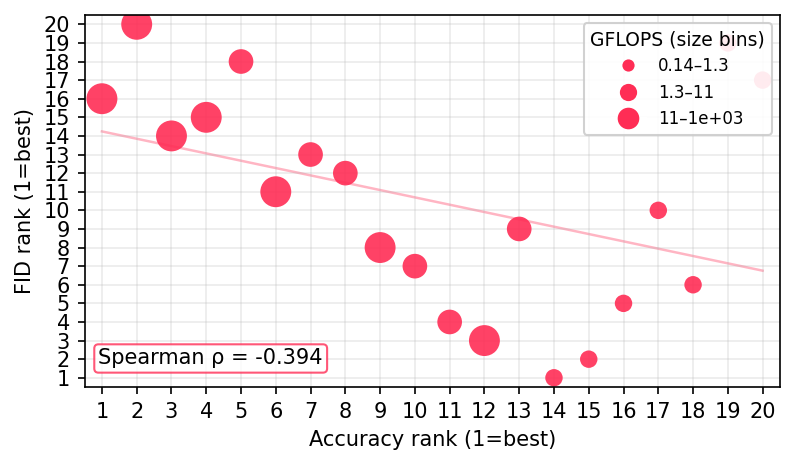

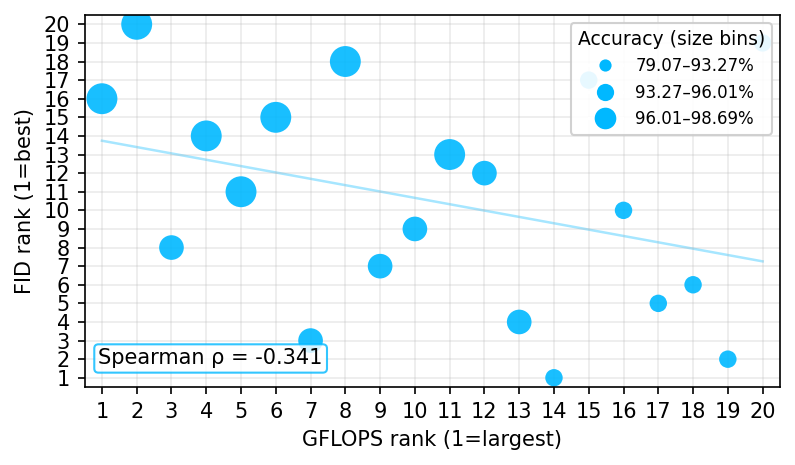

In [4]:
# Updated plots with the expanded model list (Accuracy, GFLOPS, FID).
# - Left: Accuracy rank vs FID rank (marker size = GFLOPS bins)
# - Right: GFLOPS rank vs FID rank (marker size = Accuracy bins)
# - 3-bin legends, lighter regression lines, Spearman rho annotations, legends upper-right, no titles.
# - One chart per figure; no files saved.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Expanded Data (name, weights-id string, Acc@5, GFLOPS, FID) -----
raw = [
  ("vit_h_14",          "ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1",   98.694, 1016.72, 10.71),
  ("regnet_y_128gf",    "RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_LINEAR_V1", 97.844, 127.52, 12.99),
  ("regnet_y_16gf_v1",  "RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",  97.244, 15.91,   9.97),
  ("convnext_base",     "ConvNeXt_Base_Weights.IMAGENET1K_V1",              96.870, 15.36,  10.28),
  ("efficientnet_b5",   "EfficientNet_B5_Weights.IMAGENET1K_V1",            96.628, 10.27,  11.53),
  ("regnet_y_16gf_v2",  "RegNet_Y_16GF_Weights.IMAGENET1K_V2",              96.328, 15.91,   9.63),
  ("swin_v2_t",         "Swin_V2_T_Weights.IMAGENET1K_V1",                  96.132, 5.94,    9.73),
  ("swin_t",            "Swin_T_Weights.IMAGENET1K_V1",                     95.776, 4.49,    9.65),
  ("regnet_y_32gf",     "RegNet_Y_32GF_Weights.IMAGENET1K_V1",              95.340, 32.28,   9.55),
  ("regnet_y_8gf",      "RegNet_Y_8GF_Weights.IMAGENET1K_V1",               95.048, 8.47,    9.54),
  ("regnet_y_3_2gf",    "RegNet_Y_3_2GF_Weights.IMAGENET1K_V1",             94.576, 3.18,    9.50),
  ("resnet152",         "ResNet152_Weights.IMAGENET1K_V1",                  94.046, 11.51,   9.49),
  ("resnet101",         "ResNet101_Weights.IMAGENET1K_V1",                  93.546, 7.80,    9.59),
  ("regnet_y_800mf",    "RegNet_Y_800MF_Weights.IMAGENET1K_V1",             93.136, 0.83,    9.40),
  ("mobilenet_v3_large","MobileNet_V3_Large_Weights.IMAGENET1K_V2",         92.566, 0.22,    9.44),
  ("regnet_y_400mf",    "RegNet_Y_400MF_Weights.IMAGENET1K_V1",             91.716, 0.40,    9.50),
  ("regnet_x_400mf",    "RegNet_X_400MF_Weights.IMAGENET1K_V1",             90.950, 0.41,    9.60),
  ("mobilenet_v2",      "MobileNet_V2_Weights.IMAGENET1K_V1",               90.286, 0.30,    9.52),
  ("shufflenet_v2_x1_0","ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1",         88.316, 0.14,   11.57),
  ("alexnet",           "AlexNet_Weights.IMAGENET1K_V1",                    79.066, 0.71,   11.20),
]

names     = np.array([r[0] for r in raw])
accuracy  = np.array([r[2] for r in raw], dtype=float)
gflops    = np.array([r[3] for r in raw], dtype=float)
fid       = np.array([r[4] for r in raw], dtype=float)
N = len(fid)

# ----- Ranks -----
def ranks_from_values(x, ascending=True):
    order = np.argsort(x if ascending else -x)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(x)+1, dtype=float)
    return ranks

acc_rank    = ranks_from_values(accuracy, ascending=False)  # 1 = best Accuracy
fid_rank    = ranks_from_values(fid,       ascending=True)  # 1 = best FID
gflops_rank = ranks_from_values(gflops,    ascending=False) # 1 = largest compute

# Spearman rho
def spearman_rho(x, y):
    xm = x.mean(); ym = y.mean()
    num = ((x - xm) * (y - ym)).sum()
    den = np.sqrt(((x - xm)**2).sum() * ((y - ym)**2).sum())
    return float(num / den)

rho_acc_fid    = spearman_rho(acc_rank,    fid_rank)
rho_gflops_fid = spearman_rho(gflops_rank, fid_rank)

# ----- Bin helpers (3 bins) -----
N_BINS = 3
SIZE_LEVELS_G = np.array([70, 140, 220], dtype=float)  # marker sizes (pt^2) for GFLOPS-driven sizes
SIZE_LEVELS_A = np.array([70, 140, 220], dtype=float)  # marker sizes (pt^2) for Accuracy-driven sizes

def quantile_edges(x, n_bins):
    e = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    e = np.unique(e)
    if e.size < n_bins + 1:
        e = np.linspace(float(x.min()), float(x.max()), n_bins + 1)
    return e

def log_quantile_edges(x, n_bins):
    lx = np.log10(x + 1e-12)
    e = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    e = np.unique(e)
    if e.size < n_bins + 1:
        e = np.linspace(lx.min(), lx.max(), n_bins + 1)
    return 10**e

def sizes_from_bins(x, edges, size_levels):
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(size_levels)-1)
    return size_levels[idx]

# Left: size by GFLOPS (log-binned)
edges_gflops = log_quantile_edges(gflops, N_BINS)
sizes_left = sizes_from_bins(gflops, edges_gflops, SIZE_LEVELS_G)

# Right: size by Accuracy (binned)
edges_acc = quantile_edges(accuracy, N_BINS)
sizes_right = sizes_from_bins(accuracy, edges_acc, SIZE_LEVELS_A)

# Legend formatting
LEG_FONTSIZE = 8
LEG_TITLE_FONTSIZE = 9
LEG_MARKER_SCALE = 0.7

def format_axes(ax, xlab):
    ax.set_xlabel(xlab)
    ax.set_ylabel("FID rank (1=best)")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0.5, N + 0.5); ax.set_ylim(0.5, N + 0.5)
    ax.set_xticks(range(1, N+1)); ax.set_yticks(range(1, N+1))

# ===== Left: Accuracy rank vs FID rank (size = GFLOPS) =====
plt.figure(figsize=(5.4, 3.2), dpi=150)
ax = plt.gca()
ax.scatter(acc_rank, fid_rank, s=sizes_left, c="#FF2D55", marker='o', alpha=0.9, edgecolors='none', zorder=2)
# Regression (light)
m1, b1 = np.polyfit(acc_rank, fid_rank, 1)
x1 = np.array([1, N], dtype=float); y1 = m1 * x1 + b1
ax.plot(x1, y1, color="#FF2D55", linewidth=1.2, alpha=0.35, zorder=1)

format_axes(ax, "Accuracy rank (1=best)")

ax.text(0.02, 0.05, f"Spearman ρ = {rho_acc_fid:.3f}", transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#FF2D55", alpha=0.8))

# Legend — GFLOPS bins (numeric ranges)
handles_g = []
for b, sz in enumerate(SIZE_LEVELS_G):
    lo = edges_gflops[b]
    hi = edges_gflops[b+1] if b+1 < len(edges_gflops) else None
    label = (f"{lo:.2g}–{hi:.2g}" if hi is not None else f">{lo:.2g}")
    handles_g.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#FF2D55",
                            markeredgecolor='none', markersize=(sz**0.5)*LEG_MARKER_SCALE))
ax.legend(handles=handles_g, title="GFLOPS (size bins)",
          loc='upper right', framealpha=0.9, prop={'size': LEG_FONTSIZE}, title_fontsize=LEG_TITLE_FONTSIZE)

plt.tight_layout()
plt.show()

# ===== Right: GFLOPS rank vs FID rank (size = Accuracy) =====
plt.figure(figsize=(5.4, 3.2), dpi=150)
ax = plt.gca()
ax.scatter(gflops_rank, fid_rank, s=sizes_right, c="#00B8FF", marker='o', alpha=0.9, edgecolors='none', zorder=2)
# Regression (light)
m2, b2 = np.polyfit(gflops_rank, fid_rank, 1)
x2 = np.array([1, N], dtype=float); y2 = m2 * x2 + b2
ax.plot(x2, y2, color="#00B8FF", linewidth=1.2, alpha=0.35, zorder=1)

format_axes(ax, "GFLOPS rank (1=largest)")

ax.text(0.02, 0.05, f"Spearman ρ = {rho_gflops_fid:.3f}", transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#00B8FF", alpha=0.8))

# Legend — Accuracy bins (percent ranges)
handles_a = []
for b, sz in enumerate(SIZE_LEVELS_A):
    lo = edges_acc[b]
    hi = edges_acc[b+1] if b+1 < len(edges_acc) else None
    label = (f"{lo:.2f}–{hi:.2f}%" if hi is not None else f">{lo:.2f}%")
    handles_a.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#00B8FF",
                            markeredgecolor='none', markersize=(sz**0.5)*LEG_MARKER_SCALE))
ax.legend(handles=handles_a, title="Accuracy (size bins)",
          loc='upper right', framealpha=0.9, prop={'size': LEG_FONTSIZE}, title_fontsize=LEG_TITLE_FONTSIZE)

plt.tight_layout()
plt.show()


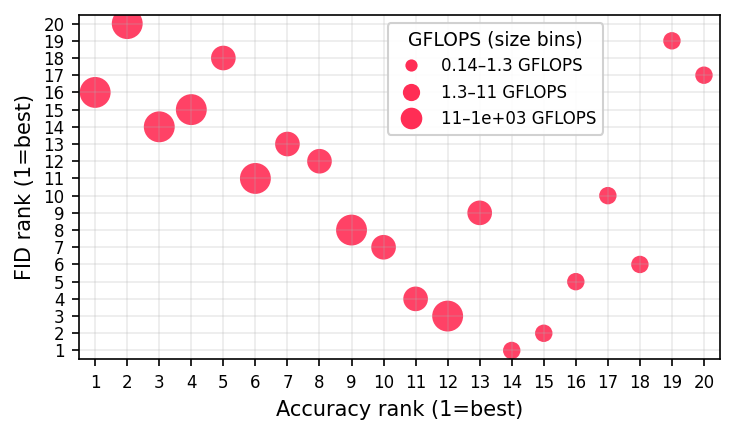

In [25]:
# Accuracy/GFLOPS vs FID (ranks) — **Accuracy rank vs FID rank only**
# - Marker size = GFLOPS bins (3, log-quantile)
# - Legend at upper center
# - Quadratic fit **removed**
# - One chart per figure; no file saving.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Expanded Data (name, weights-id string, Acc@5, GFLOPS, FID) -----
raw = [
  ("vit_h_14",          "ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1",   98.694, 1016.72, 10.71),
  ("regnet_y_128gf",    "RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_LINEAR_V1", 97.844, 127.52, 12.99),
  ("regnet_y_16gf_v1",  "RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",  97.244, 15.91,   9.97),
  ("convnext_base",     "ConvNeXt_Base_Weights.IMAGENET1K_V1",              96.870, 15.36,  10.28),
  ("efficientnet_b5",   "EfficientNet_B5_Weights.IMAGENET1K_V1",            96.628, 10.27,  11.53),
  ("regnet_y_16gf_v2",  "RegNet_Y_16GF_Weights.IMAGENET1K_V2",              96.328, 15.91,   9.63),
  ("swin_v2_t",         "Swin_V2_T_Weights.IMAGENET1K_V1",                  96.132, 5.94,    9.73),
  ("swin_t",            "Swin_T_Weights.IMAGENET1K_V1",                     95.776, 4.49,    9.65),
  ("regnet_y_32gf",     "RegNet_Y_32GF_Weights.IMAGENET1K_V1",              95.340, 32.28,   9.55),
  ("regnet_y_8gf",      "RegNet_Y_8GF_Weights.IMAGENET1K_V1",               95.048, 8.47,    9.54),
  ("regnet_y_3_2gf",    "RegNet_Y_3_2GF_Weights.IMAGENET1K_V1",             94.576, 3.18,    9.50),
  ("resnet152",         "ResNet152_Weights.IMAGENET1K_V1",                  94.046, 11.51,   9.49),
  ("resnet101",         "ResNet101_Weights.IMAGENET1K_V1",                  93.546, 7.80,    9.59),
  ("regnet_y_800mf",    "RegNet_Y_800MF_Weights.IMAGENET1K_V1",             93.136, 0.83,    9.40),
  ("mobilenet_v3_large","MobileNet_V3_Large_Weights.IMAGENET1K_V2",         92.566, 0.22,    9.44),
  ("regnet_y_400mf",    "RegNet_Y_400MF_Weights.IMAGENET1K_V1",             91.716, 0.40,    9.50),
  ("regnet_x_400mf",    "RegNet_X_400MF_Weights.IMAGENET1K_V1",             90.950, 0.41,    9.60),
  ("mobilenet_v2",      "MobileNet_V2_Weights.IMAGENET1K_V1",               90.286, 0.30,    9.52),
  ("shufflenet_v2_x1_0","ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1",         88.316, 0.14,   11.57),
  ("alexnet",           "AlexNet_Weights.IMAGENET1K_V1",                    79.066, 0.71,   11.20),
]

names     = np.array([r[0] for r in raw])
accuracy  = np.array([r[2] for r in raw], dtype=float)
gflops    = np.array([r[3] for r in raw], dtype=float)
fid       = np.array([r[4] for r in raw], dtype=float)
N = len(fid)

# ----- Ranks (1 = best) -----
def ranks_from_values(x, ascending=True):
    order = np.argsort(x if ascending else -x)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(x)+1, dtype=float)
    return ranks

acc_rank    = ranks_from_values(accuracy, ascending=False)  # Accuracy rank
fid_rank    = ranks_from_values(fid,       ascending=True)  # FID rank

# ----- Bin helpers (3 bins) -----
N_BINS = 3
SIZE_LEVELS_G = np.array([70, 140, 220], dtype=float)  # marker sizes (pt^2) for GFLOPS-driven sizes

def log_quantile_edges(x, n_bins):
    lx = np.log10(x + 1e-12)
    e  = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    e  = np.unique(e)
    if e.size < n_bins + 1: e = np.linspace(lx.min(), lx.max(), n_bins + 1)
    return 10**e

def sizes_from_bins(x, edges, size_levels):
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(size_levels)-1)
    return size_levels[idx]

edges_gflops = log_quantile_edges(gflops, N_BINS)
sizes_left   = sizes_from_bins(gflops, edges_gflops, SIZE_LEVELS_G)

# ----- Plot: Accuracy rank vs FID rank (size = GFLOPS bins) -----
plt.figure(figsize=(5, 3), dpi=150)
plt.scatter(acc_rank, fid_rank, s=sizes_left, c="#FF2D55", marker='o', alpha=0.9, edgecolors='none')
plt.xlabel("Accuracy rank (1=best)")
plt.ylabel("FID rank (1=best)")
plt.grid(True, alpha=0.25)
plt.xlim(0.5, N + 0.5); plt.ylim(0.5, N + 0.5)
plt.xticks(range(1, N+1), fontsize=8); plt.yticks(range(1, N+1), fontsize=8)

# Legend — GFLOPS bins (upper center)
handles = []
for b, sz in enumerate(SIZE_LEVELS_G):
    lo = edges_gflops[b]
    hi = edges_gflops[b+1] if b+1 < len(edges_gflops) else np.inf
    label = f"{lo:.2g}–{hi:.2g} GFLOPS" if np.isfinite(hi) else f">{lo:.2g} GFLOPS"
    handles.append(Line2D([0],[0], marker='o', linestyle='None',
                          markersize=(sz**0.5)*0.7, label=label, markerfacecolor="#FF2D55", markeredgecolor='none'))
plt.legend(handles=handles, title="GFLOPS (size bins)", bbox_to_anchor=(0.65, 1.0),
           loc='upper center', framealpha=0.9, fontsize=8, title_fontsize=9)

plt.tight_layout(); plt.show()


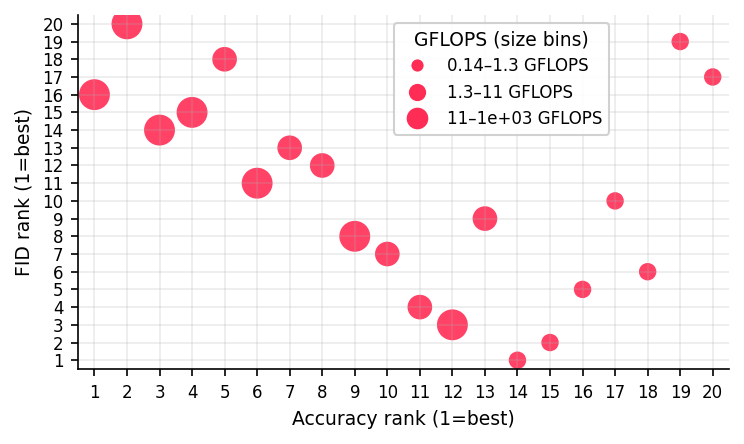

In [30]:
# Accuracy/GFLOPS vs FID (ranks) — **Accuracy rank vs FID rank only**
# - Marker size = GFLOPS bins (3, log-quantile)
# - Legend: previous style (upper center + bbox_to_anchor=(0.65, 1.0))
# - Quadratic fit removed
# - One chart per figure; no file saving.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 8, "axes.labelsize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.8, "grid.alpha": 0.25,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# (name, weights-id string, Acc@5, GFLOPS, FID)
raw = [
  ("vit_h_14","ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1",98.694,1016.72,10.71),
  ("regnet_y_128gf","RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",97.844,127.52,12.99),
  ("regnet_y_16gf_v1","RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",97.244,15.91,9.97),
  ("convnext_base","ConvNeXt_Base_Weights.IMAGENET1K_V1",96.870,15.36,10.28),
  ("efficientnet_b5","EfficientNet_B5_Weights.IMAGENET1K_V1",96.628,10.27,11.53),
  ("regnet_y_16gf_v2","RegNet_Y_16GF_Weights.IMAGENET1K_V2",96.328,15.91,9.63),
  ("swin_v2_t","Swin_V2_T_Weights.IMAGENET1K_V1",96.132,5.94,9.73),
  ("swin_t","Swin_T_Weights.IMAGENET1K_V1",95.776,4.49,9.65),
  ("regnet_y_32gf","RegNet_Y_32GF_Weights.IMAGENET1K_V1",95.340,32.28,9.55),
  ("regnet_y_8gf","RegNet_Y_8GF_Weights.IMAGENET1K_V1",95.048,8.47,9.54),
  ("regnet_y_3_2gf","RegNet_Y_3_2GF_Weights.IMAGENET1K_V1",94.576,3.18,9.50),
  ("resnet152","ResNet152_Weights.IMAGENET1K_V1",94.046,11.51,9.49),
  ("resnet101","ResNet101_Weights.IMAGENET1K_V1",93.546,7.80,9.59),
  ("regnet_y_800mf","RegNet_Y_800MF_Weights.IMAGENET1K_V1",93.136,0.83,9.40),
  ("mobilenet_v3_large","MobileNet_V3_Large_Weights.IMAGENET1K_V2",92.566,0.22,9.44),
  ("regnet_y_400mf","RegNet_Y_400MF_Weights.IMAGENET1K_V1",91.716,0.40,9.50),
  ("regnet_x_400mf","RegNet_X_400MF_Weights.IMAGENET1K_V1",90.950,0.41,9.60),
  ("mobilenet_v2","MobileNet_V2_Weights.IMAGENET1K_V1",90.286,0.30,9.52),
  ("shufflenet_v2_x1_0","ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1",88.316,0.14,11.57),
  ("alexnet","AlexNet_Weights.IMAGENET1K_V1",79.066,0.71,11.20),
]

accuracy  = np.array([r[2] for r in raw], float)
gflops    = np.array([r[3] for r in raw], float)
fid       = np.array([r[4] for r in raw], float)
N = len(fid)

def ranks_from_values(x, ascending):
    o = np.argsort(x if ascending else -x)
    r = np.empty_like(o, float); r[o] = np.arange(1, len(x)+1); return r

acc_rank = ranks_from_values(accuracy, ascending=False)  # 1=best
fid_rank = ranks_from_values(fid,       ascending=True)  # 1=best

def logq_edges(x, n=3):
    lx = np.log10(x + 1e-12)
    q  = np.quantile(lx, np.linspace(0, 1, n+1))
    if len(np.unique(q)) < n+1: q = np.linspace(lx.min(), lx.max(), n+1)
    return 10**q

edges = logq_edges(gflops, 3)
sizes = np.array([70, 140, 220], float)
svals = sizes[np.clip(np.digitize(gflops, edges) - 1, 0, len(sizes)-1)]

fig, ax = plt.subplots(figsize=(5.0, 3.0), dpi=150)
ax.scatter(acc_rank, fid_rank, s=svals, c="#FF2D55", marker='o', alpha=0.9, linewidths=0.0)
ax.set_xlabel("Accuracy rank (1=best)")
ax.set_ylabel("FID rank (1=best)")
ax.grid(True, alpha=0.25)
ax.set_xlim(0.5, N+0.5); ax.set_ylim(0.5, N+0.5)
ax.set_xticks(range(1, N+1)); ax.set_yticks(range(1, N+1))
ax.tick_params(labelsize=8, width=0.8)
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left","bottom"): ax.spines[s].set_linewidth(0.8)

# Legend — previous style (upper center + bbox_to_anchor=(0.65, 1.0))
handles = []
for i, sz in enumerate(sizes):
    lo = edges[i]; hi = edges[i+1] if i+1 < len(edges) else np.inf
    label = f"{lo:.2g}–{hi:.2g} GFLOPS" if np.isfinite(hi) else f">{lo:.2g} GFLOPS"
    handles.append(Line2D([0],[0], marker='o', linestyle='None',
                          markersize=(sz**0.5)*0.7, label=label,
                          markerfacecolor="#FF2D55", markeredgecolor='none'))
ax.legend(handles=handles, title="GFLOPS (size bins)",
          loc='upper center', bbox_to_anchor=(0.65, 1.0),
          framealpha=0.9, fontsize=8, title_fontsize=9)

plt.tight_layout(); plt.show()


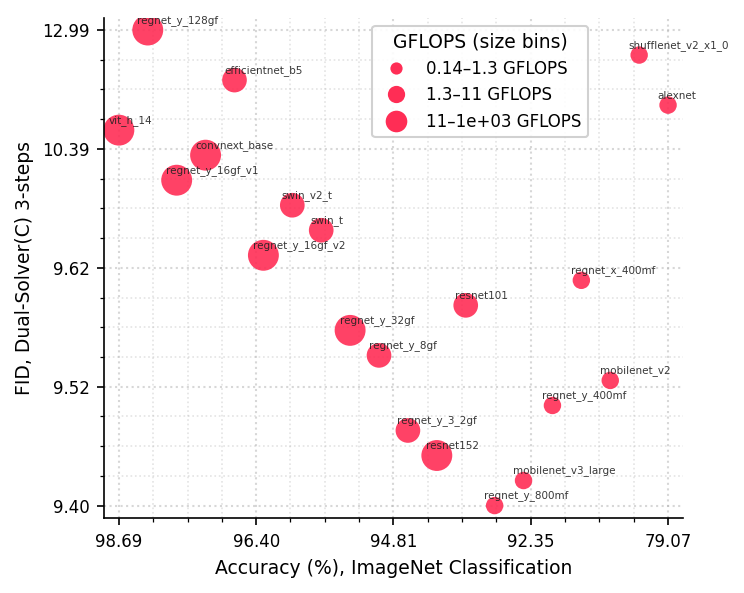

In [15]:
# Accuracy/GFLOPS vs FID (ranks) — **Accuracy rank vs FID rank only**
# - Scatter 위치는 rank(1=best)
# - 아랫축: Accuracy(%) coarse ticks, 왼쪽축: FID coarse ticks
# - Marker size = GFLOPS bins (3, log-quantile)
# - Legend: previous style (upper center + bbox_to_anchor=(0.65, 1.0))
# - 모델명 라벨 표시, grid는 살짝 더 진하게

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 8, "axes.labelsize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.8, "grid.alpha": 0.25,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# (name, weights-id, Acc@5, GFLOPS, FID)
raw = [
  ("vit_h_14","ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1",98.694,1016.72,10.71),
  ("regnet_y_128gf","RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",97.844,127.52,12.99),
  ("regnet_y_16gf_v1","RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",97.244,15.91,9.97),
  ("convnext_base","ConvNeXt_Base_Weights.IMAGENET1K_V1",96.870,15.36,10.28),
  ("efficientnet_b5","EfficientNet_B5_Weights.IMAGENET1K_V1",96.628,10.27,11.53),
  ("regnet_y_16gf_v2","RegNet_Y_16GF_Weights.IMAGENET1K_V2",96.328,15.91,9.63),
  ("swin_v2_t","Swin_V2_T_Weights.IMAGENET1K_V1",96.132,5.94,9.73),
  ("swin_t","Swin_T_Weights.IMAGENET1K_V1",95.776,4.49,9.65),
  ("regnet_y_32gf","RegNet_Y_32GF_Weights.IMAGENET1K_V1",95.340,32.28,9.55),
  ("regnet_y_8gf","RegNet_Y_8GF_Weights.IMAGENET1K_V1",95.048,8.47,9.54),
  ("regnet_y_3_2gf","RegNet_Y_3_2GF_Weights.IMAGENET1K_V1",94.576,3.18,9.50),
  ("resnet152","ResNet152_Weights.IMAGENET1K_V1",94.046,11.51,9.49),
  ("resnet101","ResNet101_Weights.IMAGENET1K_V1",93.546,7.80,9.59),
  ("regnet_y_800mf","RegNet_Y_800MF_Weights.IMAGENET1K_V1",93.136,0.83,9.40),
  ("mobilenet_v3_large","MobileNet_V3_Large_Weights.IMAGENET1K_V2",92.566,0.22,9.44),
  ("regnet_y_400mf","RegNet_Y_400MF_Weights.IMAGENET1K_V1",91.716,0.40,9.50),
  ("regnet_x_400mf","RegNet_X_400MF_Weights.IMAGENET1K_V1",90.950,0.41,9.60),
  ("mobilenet_v2","MobileNet_V2_Weights.IMAGENET1K_V1",90.286,0.30,9.52),
  ("shufflenet_v2_x1_0","ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1",88.316,0.14,11.57),
  ("alexnet","AlexNet_Weights.IMAGENET1K_V1",79.066,0.71,11.20),
]

names     = np.array([r[0] for r in raw])
accuracy  = np.array([r[2] for r in raw], float)
gflops    = np.array([r[3] for r in raw], float)
fid       = np.array([r[4] for r in raw], float)
N = len(fid)

def ranks_from_values(x, ascending):
    o = np.argsort(x if ascending else -x)
    r = np.empty_like(o, float); r[o] = np.arange(1, len(x)+1); return r

# 위치는 rank 좌표
acc_rank = ranks_from_values(accuracy, ascending=False)  # 1=best
fid_rank = ranks_from_values(fid,       ascending=True)  # 1=best

# GFLOPS 3-bin → 마커 크기
def logq_edges(x, n=3):
    lx = np.log10(x + 1e-12)
    q  = np.quantile(lx, np.linspace(0,1,n+1))
    if len(np.unique(q)) < n+1: q = np.linspace(lx.min(), lx.max(), n+1)
    return 10**q

edges = logq_edges(gflops, 3)
sizes = np.array([70, 140, 220], float)
svals = sizes[np.clip(np.digitize(gflops, edges) - 1, 0, len(sizes)-1)]

fig, ax = plt.subplots(figsize=(5.0, 4.0), dpi=150)
sc = ax.scatter(acc_rank, fid_rank, s=svals, c="#FF2D55", marker='o', alpha=0.9, linewidths=0.0)

# --- 모델명 라벨 (간단히 오프셋) ---
for x, y, label in zip(acc_rank, fid_rank, names):
    ax.annotate(label, (x, y), xytext=(-5, 2), textcoords="offset points",
                fontsize=5, color="#222", ha="left", va="bottom", alpha=0.9)

# --- 하단: Accuracy(%) coarse ticks (quantiles) ---
acc_desc = np.sort(accuracy)[::-1]; rank_desc = np.arange(1, N+1, dtype=float)
acc_ticks = np.quantile(accuracy, [0,.25,.5,.75,1.0])
acc_pos   = np.interp(acc_ticks, acc_desc[::-1], rank_desc[::-1])
ord_ = np.argsort(acc_pos); acc_pos, acc_ticks = acc_pos[ord_], acc_ticks[ord_]
ax.set_xlim(0.5, N+0.5); ax.set_xticks(acc_pos); ax.set_xticklabels([f"{v:.2f}" for v in acc_ticks])
ax.set_xlabel("Accuracy (%), ImageNet Classification")

# --- 좌측: FID coarse ticks (quantiles) ---
fid_ticks = np.quantile(fid, [0,.25,.5,.75,1.0])
fid_pos   = np.interp(fid_ticks, np.sort(fid), np.arange(1, N+1, dtype=float))
ax.set_ylim(0.5, N+0.5); ax.set_yticks(fid_pos); ax.set_yticklabels([f"{v:.2f}" for v in fid_ticks])
ax.set_ylabel("FID, Dual-Solver(C) 3-steps")

# --- Grid: major + minor (살짝 더 진하게) ---
ax.set_axisbelow(True)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(which="major", linestyle=":", linewidth=1.0, alpha=0.50)  # 진하게
ax.grid(which="minor", linestyle=":", linewidth=0.8, alpha=0.35)  # 보조

# 스파인/틱
for s in ("top","right"): ax.spines[s].set_visible(False)
for s in ("left","bottom"): ax.spines[s].set_linewidth(0.8)
ax.tick_params(width=0.8)

# Legend — previous style (upper center + bbox_to_anchor=(0.65, 1.0))
handles = []
for i, sz in enumerate(sizes):
    lo = edges[i]; hi = edges[i+1] if i+1 < len(edges) else np.inf
    label = f"{lo:.2g}–{hi:.2g} GFLOPS" if np.isfinite(hi) else f">{lo:.2g} GFLOPS"
    handles.append(Line2D([0],[0], marker='o', linestyle='None',
                          markersize=(sz**0.5)*0.7, label=label,
                          markerfacecolor="#FF2D55", markeredgecolor='none'))
ax.legend(handles=handles, title="GFLOPS (size bins)",
          loc='upper center', bbox_to_anchor=(0.65, 1.0),
          framealpha=0.9, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


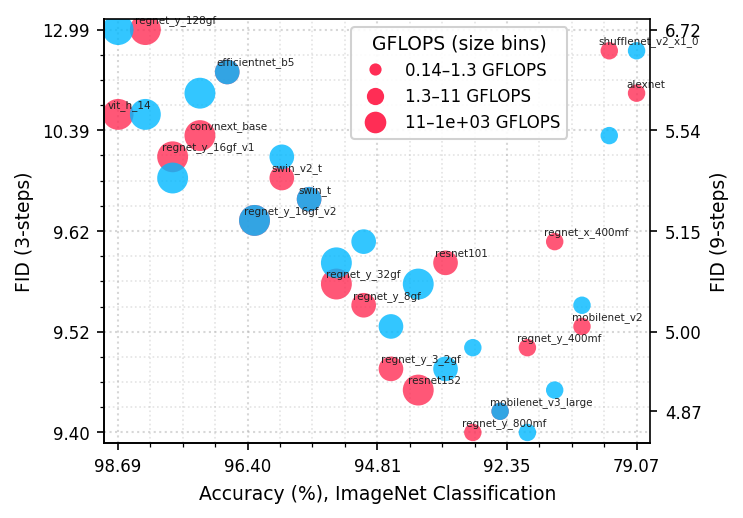

In [1]:
# Accuracy/GFLOPS vs FID (ranks) — **Accuracy rank vs FID rank only**
# - Scatter 위치는 rank(1=best)
# - 아랫축: Accuracy(%) coarse ticks
# - 왼쪽축: FID(3-steps) coarse ticks, 오른쪽축: FID(9-steps) coarse ticks
# - Marker size = GFLOPS bins (3, log-quantile)
# - Legend: **3-steps 때 쓰던 것 그대로(GFLOPS size bins만, upper center + bbox_to_anchor=(0.65, 1.0))**
# - 모델명 라벨: **3-steps만 표시**, 9-steps는 표시하지 않음
# - Grid는 살짝 더 진하고 minor 포함

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 8, "axes.labelsize": 9, "legend.fontsize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.8, "grid.alpha": 0.25,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# (name, weights-id, Acc@5, GFLOPS, FID_3steps)
raw = [
  ("vit_h_14","ViT_H_14_Weights.IMAGENET1K_SWAG_E2E_V1",98.694,1016.72,10.71),
  ("regnet_y_128gf","RegNet_Y_128GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",97.844,127.52,12.99),
  ("regnet_y_16gf_v1","RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_LINEAR_V1",97.244,15.91,9.97),
  ("convnext_base","ConvNeXt_Base_Weights.IMAGENET1K_V1",96.870,15.36,10.28),
  ("efficientnet_b5","EfficientNet_B5_Weights.IMAGENET1K_V1",96.628,10.27,11.53),
  ("regnet_y_16gf_v2","RegNet_Y_16GF_Weights.IMAGENET1K_V2",96.328,15.91,9.63),
  ("swin_v2_t","Swin_V2_T_Weights.IMAGENET1K_V1",96.132,5.94,9.73),
  ("swin_t","Swin_T_Weights.IMAGENET1K_V1",95.776,4.49,9.65),
  ("regnet_y_32gf","RegNet_Y_32GF_Weights.IMAGENET1K_V1",95.340,32.28,9.55),
  ("regnet_y_8gf","RegNet_Y_8GF_Weights.IMAGENET1K_V1",95.048,8.47,9.54),
  ("regnet_y_3_2gf","RegNet_Y_3_2GF_Weights.IMAGENET1K_V1",94.576,3.18,9.50),
  ("resnet152","ResNet152_Weights.IMAGENET1K_V1",94.046,11.51,9.49),
  ("resnet101","ResNet101_Weights.IMAGENET1K_V1",93.546,7.80,9.59),
  ("regnet_y_800mf","RegNet_Y_800MF_Weights.IMAGENET1K_V1",93.136,0.83,9.40),
  ("mobilenet_v3_large","MobileNet_V3_Large_Weights.IMAGENET1K_V2",92.566,0.22,9.44),
  ("regnet_y_400mf","RegNet_Y_400MF_Weights.IMAGENET1K_V1",91.716,0.40,9.50),
  ("regnet_x_400mf","RegNet_X_400MF_Weights.IMAGENET1K_V1",90.950,0.41,9.60),
  ("mobilenet_v2","MobileNet_V2_Weights.IMAGENET1K_V1",90.286,0.30,9.52),
  ("shufflenet_v2_x1_0","ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1",88.316,0.14,11.57),
  ("alexnet","AlexNet_Weights.IMAGENET1K_V1",79.066,0.71,11.20),
]

# FID (9-steps) — 제공값
fid9 = np.array([
    6.72, 5.61, 5.32, 5.78, 6.01,
    5.21, 5.34, 5.29, 5.04, 5.10,
    5.01, 5.03, 4.98, 4.99, 4.87,
    4.87, 4.93, 5.03, 5.51, 6.22
], dtype=float)

names     = np.array([r[0] for r in raw])
accuracy  = np.array([r[2] for r in raw], float)
gflops    = np.array([r[3] for r in raw], float)
fid3      = np.array([r[4] for r in raw], float)
N = len(fid3)

def ranks_from_values(x, ascending):
    o = np.argsort(x if ascending else -x)
    r = np.empty_like(o, float); r[o] = np.arange(1, len(x)+1); return r

# scatter 위치(좌표)는 rank
acc_rank  = ranks_from_values(accuracy, ascending=False)  # 1=best
fid_rank3 = ranks_from_values(fid3,     ascending=True)   # 1=best
fid_rank9 = ranks_from_values(fid9,     ascending=True)   # 1=best

# GFLOPS 3-bin → marker size
def logq_edges(x, n=3):
    lx = np.log10(x + 1e-12)
    q  = np.quantile(lx, np.linspace(0,1,n+1))
    if len(np.unique(q)) < n+1: q = np.linspace(lx.min(), lx.max(), n+1)
    return 10**q

edges = logq_edges(gflops, 3)
sizes = np.array([70, 140, 220], float)
svals = sizes[np.clip(np.digitize(gflops, edges) - 1, 0, len(sizes)-1)]

fig, ax = plt.subplots(figsize=(5.0, 3.5), dpi=150)

# 3-steps(핑크) + 9-steps(블루) — 9-steps에는 모델명 라벨 X
ax.scatter(acc_rank, fid_rank3, s=svals, c="#FF2D55", marker='o', alpha=0.80, linewidths=0.0)
ax.scatter(acc_rank, fid_rank9, s=svals, c="#00B8FF", marker='o', alpha=0.80, linewidths=0.0)

# 모델명 라벨은 3-steps 위치에만
for x, y, label in zip(acc_rank, fid_rank3, names):
    ax.annotate(label, (x, y), xytext=(-5, 2), textcoords="offset points",
                fontsize=5, color="#222", ha="left", va="bottom", alpha=1.0)

# --- 하단: Accuracy(%) coarse ticks (quantiles) ---
acc_desc = np.sort(accuracy)[::-1]
rank_desc = np.arange(1, N+1, dtype=float)
acc_ticks = np.quantile(accuracy, [0,.25,.5,.75,1.0])
acc_pos   = np.interp(acc_ticks, acc_desc[::-1], rank_desc[::-1])
ord_ = np.argsort(acc_pos); acc_pos, acc_ticks = acc_pos[ord_], acc_ticks[ord_]
ax.set_xlim(0.5, N+0.5)
ax.set_xticks(acc_pos); ax.set_xticklabels([f"{v:.2f}" for v in acc_ticks])
ax.set_xlabel("Accuracy (%), ImageNet Classification")

# --- 왼쪽: FID(3-steps) coarse ticks ---
fid_ticks_l = np.quantile(fid3, [0,.25,.5,.75,1.0])
fid_pos_l   = np.interp(fid_ticks_l, np.sort(fid3), np.arange(1, N+1, dtype=float))
ax.set_ylim(0.5, N+0.5)
ax.set_yticks(fid_pos_l); ax.set_yticklabels([f"{v:.2f}" for v in fid_ticks_l])
ax.set_ylabel("FID (3-steps)")

# --- 오른쪽: FID(9-steps) coarse ticks ---
right = ax.twinx()
right.set_ylim(ax.get_ylim())
fid_ticks_r = np.quantile(fid9, [0,.25,.5,.75,1.0])
fid_pos_r   = np.interp(fid_ticks_r, np.sort(fid9), np.arange(1, N+1, dtype=float))
right.set_yticks(fid_pos_r); right.set_yticklabels([f"{v:.2f}" for v in fid_ticks_r])
right.set_ylabel("FID (9-steps)")

# --- Grid: major + minor (살짝 더 진하게) ---
ax.set_axisbelow(True)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))
ax.grid(which="major", linestyle=":", linewidth=1.0, alpha=0.50)
ax.grid(which="minor", linestyle=":", linewidth=0.8, alpha=0.35)

# 스파인/틱
for s in ("top","right"): ax.spines[s].set_visible(False)
for s in ("left","bottom"): ax.spines[s].set_linewidth(0.8)
ax.tick_params(width=0.8)

# Legend — **3-steps 때 쓰던 것 그대로: GFLOPS size bins만** (3-steps/9-steps 표기 X)
handles = []
for i, sz in enumerate(sizes):
    lo = edges[i]; hi = edges[i+1] if i+1 < len(edges) else np.inf
    label = f"{lo:.2g}–{hi:.2g} GFLOPS" if np.isfinite(hi) else f">{lo:.2g} GFLOPS"
    handles.append(Line2D([0],[0], marker='o', linestyle='None',
                          markersize=(sz**0.5)*0.7, label=label,
                          markerfacecolor="#FF2D55", markeredgecolor='none'))
ax.legend(handles=handles, title="GFLOPS (size bins)",
          loc='upper center', bbox_to_anchor=(0.65, 1.0),
          framealpha=0.9, fontsize=8, title_fontsize=9)

plt.tight_layout()
plt.show()


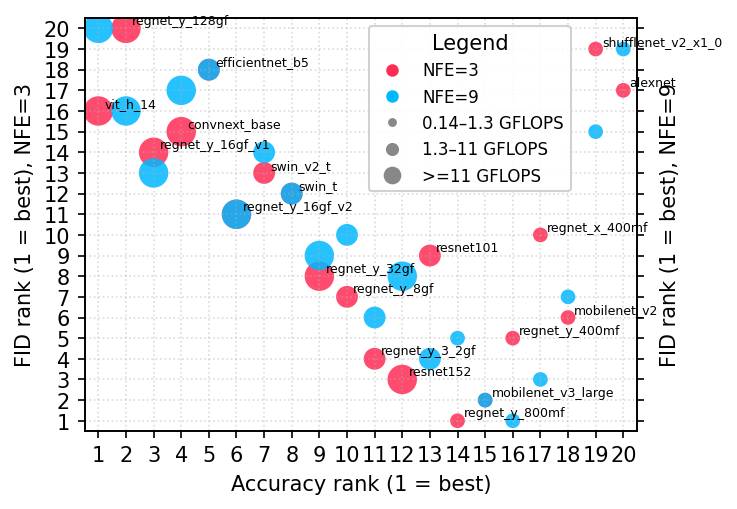

In [1]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# (name, Acc@5, GFLOPS, FID@3)
raw = [
  ("vit_h_14",98.694,1016.72,10.71), ("regnet_y_128gf",97.844,127.52,12.99),
  ("regnet_y_16gf_v1",97.244,15.91,9.97), ("convnext_base",96.870,15.36,10.28),
  ("efficientnet_b5",96.628,10.27,11.53), ("regnet_y_16gf_v2",96.328,15.91,9.63),
  ("swin_v2_t",96.132,5.94,9.73), ("swin_t",95.776,4.49,9.65),
  ("regnet_y_32gf",95.340,32.28,9.55), ("regnet_y_8gf",95.048,8.47,9.54),
  ("regnet_y_3_2gf",94.576,3.18,9.50), ("resnet152",94.046,11.51,9.49),
  ("resnet101",93.546,7.80,9.59), ("regnet_y_800mf",93.136,0.83,9.40),
  ("mobilenet_v3_large",92.566,0.22,9.44), ("regnet_y_400mf",91.716,0.40,9.50),
  ("regnet_x_400mf",90.950,0.41,9.60), ("mobilenet_v2",90.286,0.30,9.52),
  ("shufflenet_v2_x1_0",88.316,0.14,11.57), ("alexnet",79.066,0.71,11.20),
]
fid9 = np.array([6.72,5.61,5.32,5.78,6.01,5.21,5.34,5.29,5.04,5.10,
                 5.01,5.03,4.98,4.99,4.87,4.87,4.93,5.03,5.51,6.22])

names, acc5, gflops, fid3 = map(np.array, zip(*raw)); N = len(names)

# ranks (1=best)
acc_rank = np.empty(N,int); acc_rank[np.argsort(-acc5)] = np.arange(1,N+1)
r3 = np.empty(N,int); r3[np.argsort(fid3)] = np.arange(1,N+1)
r9 = np.empty(N,int); r9[np.argsort(fid9)] = np.arange(1,N+1)

# marker sizes from GFLOPS (3 log-quantile bins)
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
bin_idx = np.clip(np.digitize(gflops, edges, right=False) - 1, 0, 2)
svals = sizes[bin_idx]

fig, ax = plt.subplots(figsize=(5.0,3.5), dpi=150)
s1 = ax.scatter(acc_rank, r3, s=svals, c="#FF2D55", alpha=.85, edgecolors="none", label="NFE=3")
s2 = ax.scatter(acc_rank, r9, s=svals, c="#00B8FF", alpha=.85, edgecolors="none", label="NFE=9")

# label only FID@3 points
for x,y,t in zip(acc_rank, r3, names):
    ax.annotate(t, (x,y), xytext=(3,2), textcoords="offset points", fontsize=6)

# rank ticks 1..20
ticks = np.arange(1, N+1)
ax.set_xlim(.5, N+.5); ax.set_ylim(.5, N+.5)
ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks])
ax.set_yticks(ticks); ax.set_yticklabels([str(t) for t in ticks])

# right y-axis label
right = ax.twinx()
right.set_ylim(ax.get_ylim()); right.set_yticks(ticks); right.set_yticklabels([""]*N)
right.set_ylabel("FID rank (1 = best), NFE=9")

ax.set_xlabel("Accuracy rank (1 = best)")
ax.set_ylabel("FID rank (1 = best), NFE=3")
ax.grid(True, ls=":", alpha=.45)

# --- legend: NFE colors + GFLOPS size bins ---
size_handles = []
for i in range(3):
    lo, hi = edges[i], edges[i+1]
    lbl = f"{lo:.2g}–{hi:.2g} GFLOPS" if i < 2 else f">={lo:.2g} GFLOPS"
    size_handles.append(Line2D([0],[0], marker='o', linestyle='',
                               markersize=(sizes[i]**0.5)*0.6, markerfacecolor="#888",
                               markeredgecolor='none', label=lbl))
handles = [Line2D([0],[0], marker='o', linestyle='', markerfacecolor="#FF2D55",
                  markeredgecolor='none', label="NFE=3"),
           Line2D([0],[0], marker='o', linestyle='', markerfacecolor="#00B8FF",
                  markeredgecolor='none', label="NFE=9")] + size_handles

ax.legend(handles=handles, bbox_to_anchor=(0.5, 0.56), framealpha=.9, fontsize=8, title="Legend")

plt.tight_layout(); plt.show()


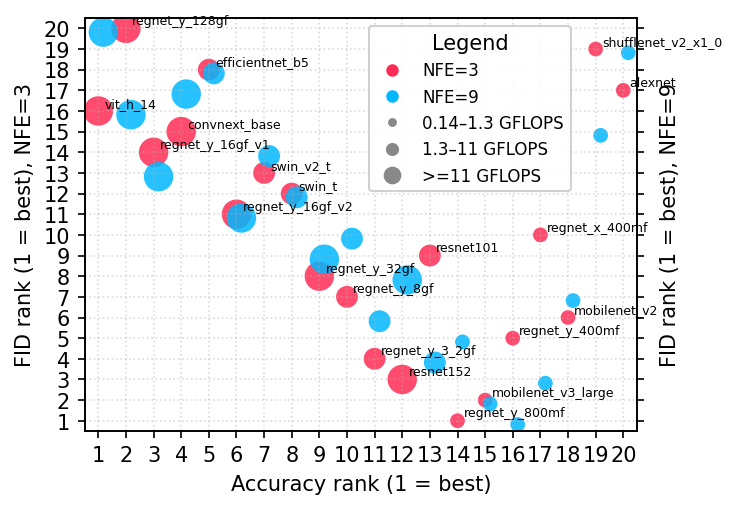

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# (name, Acc@5, GFLOPS, FID@3)
raw = [
    ("vit_h_14",98.694,1016.72,10.71), ("regnet_y_128gf",97.844,127.52,12.99),
    ("regnet_y_16gf_v1",97.244,15.91,9.97), ("convnext_base",96.870,15.36,10.28),
    ("efficientnet_b5",96.628,10.27,11.53), ("regnet_y_16gf_v2",96.328,15.91,9.63),
    ("swin_v2_t",96.132,5.94,9.73), ("swin_t",95.776,4.49,9.65),
    ("regnet_y_32gf",95.340,32.28,9.55), ("regnet_y_8gf",95.048,8.47,9.54),
    ("regnet_y_3_2gf",94.576,3.18,9.50), ("resnet152",94.046,11.51,9.49),
    ("resnet101",93.546,7.80,9.59), ("regnet_y_800mf",93.136,0.83,9.40),
    ("mobilenet_v3_large",92.566,0.22,9.44), ("regnet_y_400mf",91.716,0.40,9.50),
    ("regnet_x_400mf",90.950,0.41,9.60), ("mobilenet_v2",90.286,0.30,9.52),
    ("shufflenet_v2_x1_0",88.316,0.14,11.57), ("alexnet",79.066,0.71,11.20),
]

fid9 = np.array([
    6.72, 5.61, 5.32, 5.78, 6.01, 5.21, 5.34, 5.29, 5.04, 5.10,
    5.01, 5.03, 4.98, 4.99, 4.87, 4.87, 4.93, 5.03, 5.51, 6.22
])

names, acc5, gflops, fid3 = map(np.array, zip(*raw))
N = len(names)

# ranks (1 = best)
acc_rank = np.empty(N, int); acc_rank[np.argsort(-acc5)] = np.arange(1, N+1)
r3 = np.empty(N, int);       r3[np.argsort(fid3)]        = np.arange(1, N+1)
r9 = np.empty(N, int);       r9[np.argsort(fid9)]        = np.arange(1, N+1)

# marker sizes from GFLOPS (3 log-quantile bins)
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
bin_idx = np.clip(np.digitize(gflops, edges, right=False) - 1, 0, 2)
svals = sizes[bin_idx]

fig, ax = plt.subplots(figsize=(5.0, 3.5), dpi=150)

# 빨간 점: NFE=3 (그대로)
s1 = ax.scatter(
    acc_rank, r3,
    s=svals,
    c="#FF2D55",
    alpha=.85,
    edgecolors="none",
    label="NFE=3",
)

# 파란 점: NFE=9 (살짝 우상향으로 offset)
offset_x, offset_y = 0.18, 0.18  # 튜닝해도 됨
s2 = ax.scatter(
    acc_rank + offset_x,   # 오른쪽으로 살짝
    r9        - offset_y,  # 위쪽으로 살짝 (rank 값은 시각적으로만 이동)
    s=svals,
    c="#00B8FF",
    alpha=.85,
    edgecolors="none",
    label="NFE=9",
)

# FID@3 포인트에만 이름 라벨
for x, y, t in zip(acc_rank, r3, names):
    ax.annotate(
        t, (x, y),
        xytext=(3, 2),
        textcoords="offset points",
        fontsize=6,
    )

# rank ticks 1..20
ticks = np.arange(1, N+1)
ax.set_xlim(.5, N + .5)
ax.set_ylim(.5, N + .5)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])
ax.set_yticks(ticks)
ax.set_yticklabels([str(t) for t in ticks])

# 오른쪽 y축: NFE=9 설명용 라벨
right = ax.twinx()
right.set_ylim(ax.get_ylim())
right.set_yticks(ticks)
right.set_yticklabels([""] * N)
right.set_ylabel("FID rank (1 = best), NFE=9")

ax.set_xlabel("Accuracy rank (1 = best)")
ax.set_ylabel("FID rank (1 = best), NFE=3")
ax.grid(True, ls=":", alpha=.45)

# --- legend: NFE colors + GFLOPS size bins ---
size_handles = []
for i in range(3):
    lo, hi = edges[i], edges[i+1]
    if i < 2:
        lbl = f"{lo:.2g}–{hi:.2g} GFLOPS"
    else:
        lbl = f">={lo:.2g} GFLOPS"
    size_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=(sizes[i]**0.5) * 0.6,
            markerfacecolor="#888",
            markeredgecolor='none',
            label=lbl,
        )
    )

handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#FF2D55", markeredgecolor='none', label="NFE=3"),
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#00B8FF", markeredgecolor='none', label="NFE=9"),
] + size_handles

ax.legend(
    handles=handles,
    bbox_to_anchor=(0.5, 0.56),
    framealpha=.9,
    fontsize=8,
    title="Legend",
)

plt.tight_layout()
plt.show()


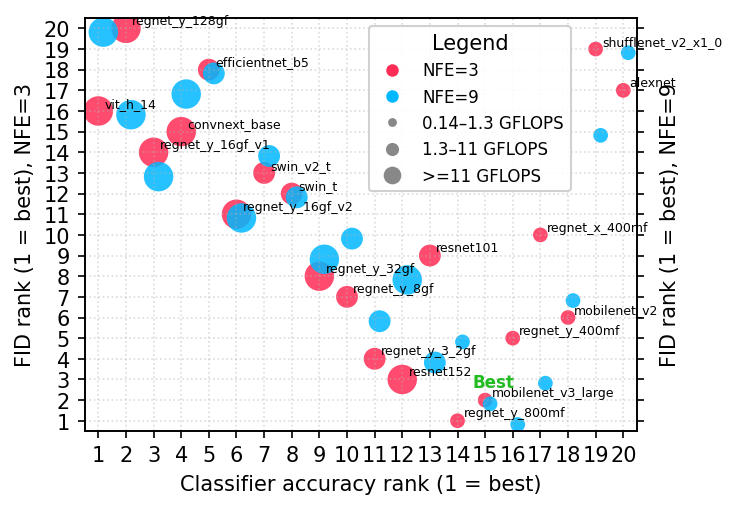

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# (name, Acc@5, GFLOPS, FID@3)
raw = [
    ("vit_h_14",98.694,1016.72,10.71), ("regnet_y_128gf",97.844,127.52,12.99),
    ("regnet_y_16gf_v1",97.244,15.91,9.97), ("convnext_base",96.870,15.36,10.28),
    ("efficientnet_b5",96.628,10.27,11.53), ("regnet_y_16gf_v2",96.328,15.91,9.63),
    ("swin_v2_t",96.132,5.94,9.73), ("swin_t",95.776,4.49,9.65),
    ("regnet_y_32gf",95.340,32.28,9.55), ("regnet_y_8gf",95.048,8.47,9.54),
    ("regnet_y_3_2gf",94.576,3.18,9.50), ("resnet152",94.046,11.51,9.49),
    ("resnet101",93.546,7.80,9.59), ("regnet_y_800mf",93.136,0.83,9.40),
    ("mobilenet_v3_large",92.566,0.22,9.44), ("regnet_y_400mf",91.716,0.40,9.50),
    ("regnet_x_400mf",90.950,0.41,9.60), ("mobilenet_v2",90.286,0.30,9.52),
    ("shufflenet_v2_x1_0",88.316,0.14,11.57), ("alexnet",79.066,0.71,11.20),
]

fid9 = np.array([
    6.72, 5.61, 5.32, 5.78, 6.01, 5.21, 5.34, 5.29, 5.04, 5.10,
    5.01, 5.03, 4.98, 4.99, 4.87, 4.87, 4.93, 5.03, 5.51, 6.22
])

names, acc5, gflops, fid3 = map(np.array, zip(*raw))
N = len(names)

# ranks (1 = best)
acc_rank = np.empty(N, int); acc_rank[np.argsort(-acc5)] = np.arange(1, N+1)
r3 = np.empty(N, int);       r3[np.argsort(fid3)]        = np.arange(1, N+1)
r9 = np.empty(N, int);       r9[np.argsort(fid9)]        = np.arange(1, N+1)

# marker sizes from GFLOPS (3 log-quantile bins)
lx = np.log10(gflops + 1e-12)
edges = 10**np.quantile(lx, [0, 1/3, 2/3, 1])
sizes = np.array([50, 110, 200], float)
bin_idx = np.clip(np.digitize(gflops, edges, right=False) - 1, 0, 2)
svals = sizes[bin_idx]

fig, ax = plt.subplots(figsize=(5.0, 3.5), dpi=150)

# 빨간 점: NFE=3
s1 = ax.scatter(
    acc_rank, r3,
    s=svals,
    c="#FF2D55",
    alpha=.85,
    edgecolors="none",
    label="NFE=3",
)

# 파란 점: NFE=9 (살짝 우상향 offset)
offset_x, offset_y = 0.18, 0.18
s2 = ax.scatter(
    acc_rank + offset_x,
    r9        - offset_y,
    s=svals,
    c="#00B8FF",
    alpha=.85,
    edgecolors="none",
    label="NFE=9",
)

# FID@3 포인트에 이름 라벨
for x, y, t in zip(acc_rank, r3, names):
    ax.annotate(
        t, (x, y),
        xytext=(3, 2),
        textcoords="offset points",
        fontsize=6,
    )

# === mark Best at mobilenet_v3_large ===
idx_best = np.where(names == "mobilenet_v3_large")[0][0]
x_best = acc_rank[idx_best]
y_best = r3[idx_best]

ax.annotate(
    "Best",
    (x_best, y_best),
    xytext=(-6, 6),                   # 살짝 오른쪽/위 위치로 조정
    textcoords="offset points",
    color="#22BB22",                   # 빨강
    fontsize=8,
    fontweight="bold",
)

# rank ticks 1..20
ticks = np.arange(1, N+1)
ax.set_xlim(.5, N + .5)
ax.set_ylim(.5, N + .5)
ax.set_xticks(ticks)
ax.set_xticklabels([str(t) for t in ticks])
ax.set_yticks(ticks)
ax.set_yticklabels([str(t) for t in ticks])

# 오른쪽 y축: NFE=9 설명용 라벨
right = ax.twinx()
right.set_ylim(ax.get_ylim())
right.set_yticks(ticks)
right.set_yticklabels([""] * N)
right.set_ylabel("FID rank (1 = best), NFE=9")

ax.set_xlabel("Classifier accuracy rank (1 = best)")
ax.set_ylabel("FID rank (1 = best), NFE=3")
ax.grid(True, ls=":", alpha=.45)

# --- legend: NFE colors + GFLOPS size bins ---
size_handles = []
for i in range(3):
    lo, hi = edges[i], edges[i+1]
    if i < 2:
        lbl = f"{lo:.2g}–{hi:.2g} GFLOPS"
    else:
        lbl = f">={lo:.2g} GFLOPS"
    size_handles.append(
        Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=(sizes[i]**0.5) * 0.6,
            markerfacecolor="#888",
            markeredgecolor='none',
            label=lbl,
        )
    )

handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#FF2D55", markeredgecolor='none', label="NFE=3"),
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor="#00B8FF", markeredgecolor='none', label="NFE=9"),
] + size_handles

ax.legend(
    handles=handles,
    bbox_to_anchor=(0.5, 0.56),
    framealpha=.9,
    fontsize=8,
    title="Legend",
)

plt.tight_layout()
plt.show()
